In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc, \
    confusion_matrix
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, train_test_split


In [2]:
data_directory = Path(__name__).resolve().parent.parent / 'data'
model_dir = Path(__name__).resolve().parent.parent / 'models'

df = pd.read_csv(str(data_directory) + '/Telco_Customer_Churn.csv').drop('customerID', axis=1)
df['TotalCharges'] = df['TotalCharges'].map(lambda x: float(x) if x != ' ' else 0)

X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [3]:
print(X_train.nunique())
print(X_train.info())

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1471
TotalCharges        4959
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 5282 entries, 6661 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5282 non-null   object 
 1   SeniorCitizen     5282 non-null   int64  
 2   Partner           5282 non-null   object 
 3   Dependents        5282 non-null   object 
 4   tenure            5282 non-null   int64  
 5   PhoneService      5282 non-null   object 
 6   MultipleLines     5282 non

In [4]:
X_train.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1471
TotalCharges        4959
dtype: int64

In [5]:
cat_features = list(X_train.select_dtypes(include=['object', 'category']).columns)

model = CatBoostClassifier(random_state=42,
                           verbose=False,
                           eval_metric='AUC',
                           iterations=2000,
                           )

param_grid = {
    'depth': [3],
    'learning_rate': [0.01],
    'l2_leaf_reg': [7],
}

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_catboost = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv=strat_kfold, n_jobs=-1, n_iter=1)
grid_search_catboost.fit(X_train, y_train, cat_features=cat_features)
grid_search_catboost.best_params_

{'learning_rate': 0.01, 'l2_leaf_reg': 7, 'depth': 3}

In [10]:
best_catboost_model = grid_search_catboost.best_estimator_
# joblib.dump(best_catboost_model, model_dir / 'best_catboost_model.pkl')

y_proba = best_catboost_model.predict_proba(X_train)[:, 1]
y_pred = (y_proba > 0.25).astype(int)
clf_report = classification_report(y_train, y_pred)
fpr, tpr, thr = roc_curve(y_train, y_proba)
roc_auc = roc_auc_score(y_train, y_proba)
precision, recall, thresholds = precision_recall_curve(y_train, y_pred)
pr_auc = auc(recall, precision)
print(f'Classification report | Train Data:\n{clf_report}\nROC AUC: {roc_auc: .2f}\nPR AUC: {pr_auc: .2f}')

Classification report | Train Data:
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      3880
           1       0.52      0.84      0.64      1402

    accuracy                           0.75      5282
   macro avg       0.72      0.78      0.73      5282
weighted avg       0.82      0.75      0.77      5282

ROC AUC:  0.86
PR AUC:  0.70


In [11]:
y_proba = best_catboost_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.25).astype(int)
clf_report = classification_report(y_test, y_pred)
fpr, tpr, thr = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
pr_auc = auc(recall, precision)
print(f'Classification report | Test Data:\n{clf_report}\nROC AUC: {roc_auc: .2f}\nPR AUC: {pr_auc: .2f}')

Classification report | Test Data:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1294
           1       0.51      0.82      0.62       467

    accuracy                           0.74      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.81      0.74      0.75      1761

ROC AUC:  0.85
PR AUC:  0.69


Text(0, 0.5, 'True positive rate')

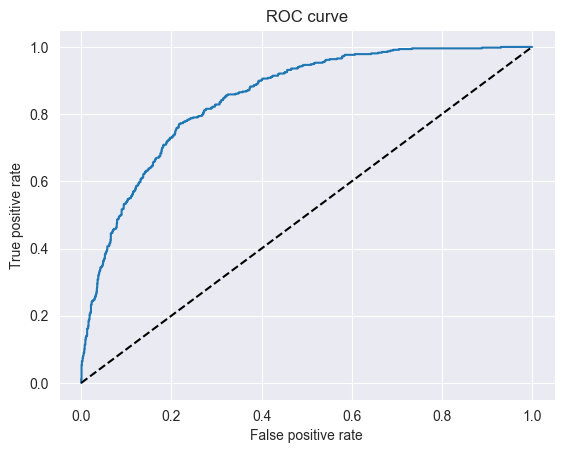

In [12]:
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

<Axes: >

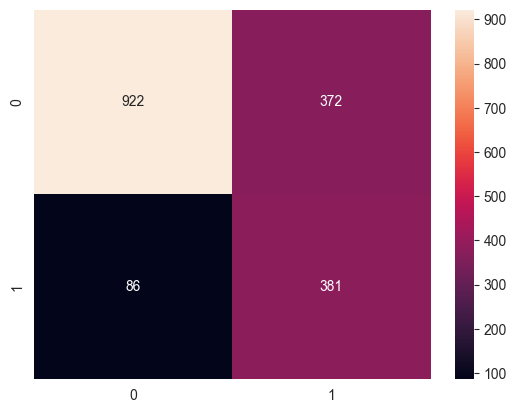

In [13]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='.4g')